In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from astropy.io import fits
import os
import numpy as np

In [8]:
master_hdu = fits.open("FLATS/master_V.fits")
master = master_hdu[0].data.astype(float)

hdus = fits.open("ngc3227/ngc3227_F2_189.fits")
science = hdus[0].data.astype(float)

data_calibrated = science / master

In [9]:
hdus[0].header["RA"], hdus[0].header["DEC"]

('10:23:30', '19:51:54,')

In [23]:
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder

mean, median, std = sigma_clipped_stats(data_calibrated, sigma=3.0)

daofind = DAOStarFinder(
    fwhm=4,
    threshold=3.5 * std,
)

sources = daofind(data_calibrated - median)

In [24]:
sources = sources[sources["flux"] > 500]

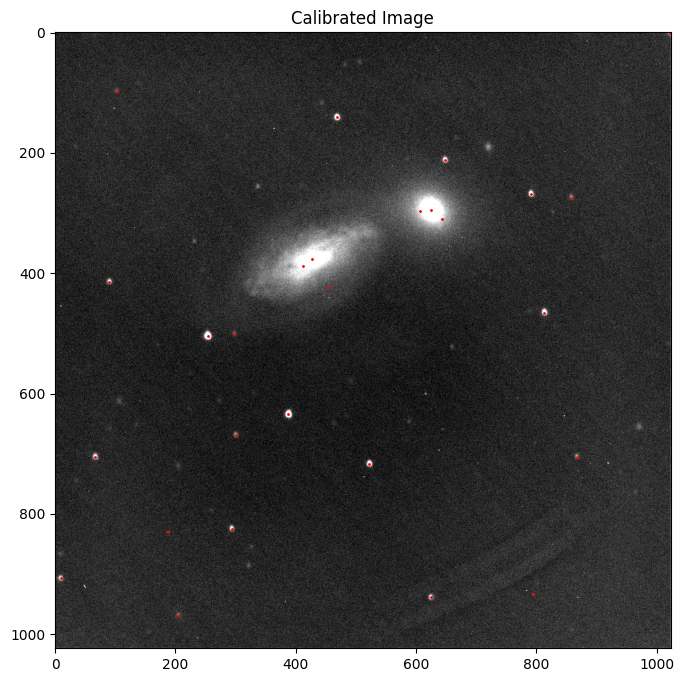

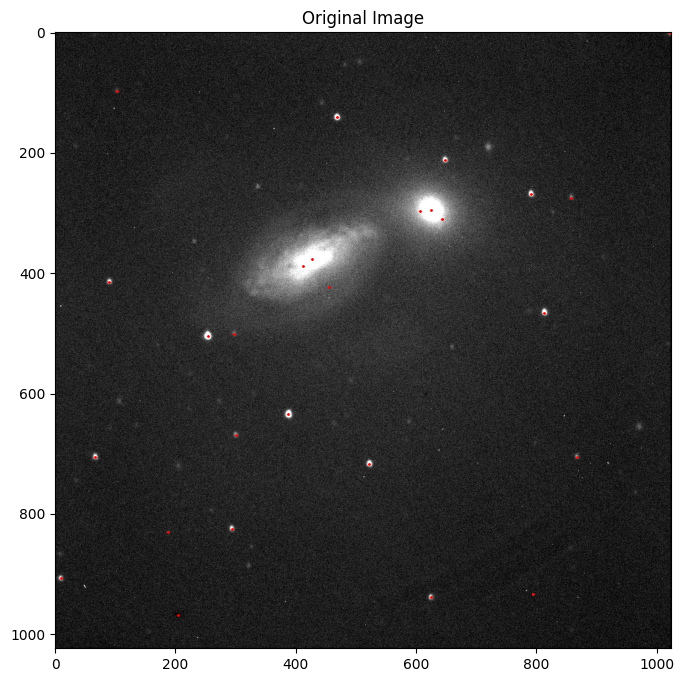

In [37]:
# plot sources over the image
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,8))
plt.title("Calibrated Image")
vmin, vmax = np.percentile(data_calibrated, [1, 99.7])
plt.imshow(data_calibrated, cmap="gray", vmin=vmin, vmax=vmax)
plt.scatter(sources["xcentroid"], sources["ycentroid"], s=1, c='red', marker='o')
plt.show()


plt.figure(figsize=(8,8))
plt.title("Original Image") 
vmin, vmax = np.percentile(hdus[0].data, [1, 99.7])
plt.imshow(hdus[0].data, cmap="gray", vmin=vmin, vmax=vmax)
plt.scatter(sources["xcentroid"], sources["ycentroid"], s=1, c='red', marker='o')
plt.show()

In [38]:
from astropy.coordinates import SkyCoord
import astropy.units as u

from astropy.coordinates import SkyCoord
import astropy.units as u


def clean_angle_string(x):
    return str(x).strip().replace(",", "").replace("'", "").replace('"', "")


def radec_to_degrees(ra, dec):
    ra = clean_angle_string(ra)
    dec = clean_angle_string(dec)

    coord = SkyCoord(ra, dec, unit=(u.hourangle, u.deg))
    return coord.ra.deg, coord.dec.deg

ra, dec = radec_to_degrees(hdus[0].header.get("RA"), hdus[0].header.get("DEC"))


In [42]:
import numpy as np
import astrometry

# sort by flux, brightest first
sources_sorted = sources[np.argsort(sources["flux"])[::-1]]

stars = np.array([
    [s["xcentroid"], s["ycentroid"]]
    for s in sources_sorted
], dtype=float)

print(f"Detected {len(stars)} stars for astrometric solution")

solver = astrometry.Solver(
    astrometry.series_5000.index_files(
        cache_directory="astrometry_cache",
        scales={4,5,7},
    )
)

solution = solver.solve(
    stars=stars,
    size_hint=astrometry.SizeHint(
        lower_arcsec_per_pixel=0.50,
        upper_arcsec_per_pixel=0.90,
    ),
    position_hint=astrometry.PositionHint(
        ra_deg=ra,
        dec_deg=dec,
        radius_deg=1,
    ),
    solution_parameters=astrometry.SolutionParameters(
    ),
)

print(solution.matches)

Detected 27 stars for astrometric solution
[]
